Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0253 - val_loss: 0.0134
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0137 - val_loss: 0.0123
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0135 - val_loss: 0.0107
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0120 - val_loss: 0.0100
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - val_loss: 0.0089
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107 - val_loss: 0.0085
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0088 - val_loss: 0.0077
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0074
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0078 - val_loss: 0.0063
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0057
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0075 - val_loss: 0.0056
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0070 - val_loss: 0.0052

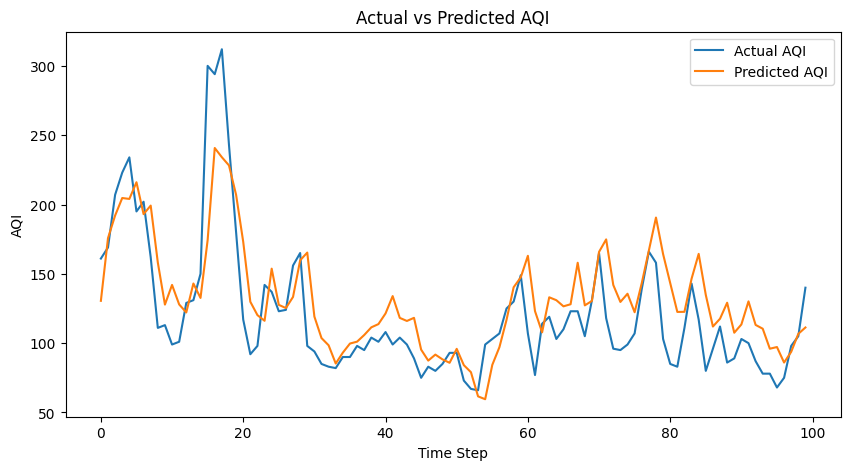

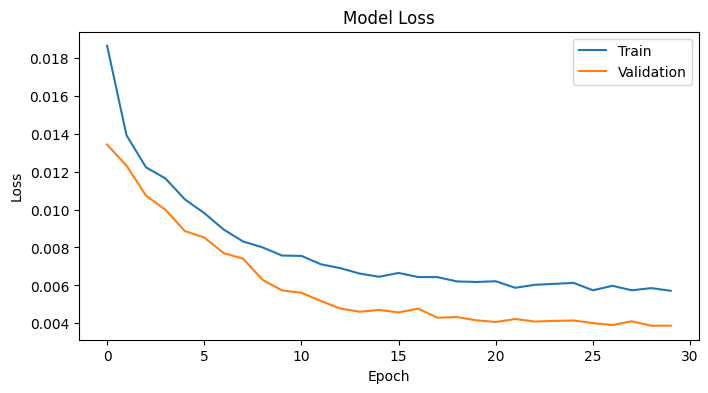

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# -----------------------------
# Step 1: Load dataset
# -----------------------------
data = pd.read_csv("city_day.csv")

# -----------------------------
# Step 2: Filter one city (important)
# -----------------------------
data = data[data['City'] == 'Delhi']
data = data.sort_values('Date')

# -----------------------------
# Step 3: Select features and target
# -----------------------------
data = data[['PM2.5','PM10','NO2','CO','SO2','O3','AQI']]
data = data.dropna()

X = data[['PM2.5','PM10','NO2','CO','SO2','O3']]
y = data[['AQI']]

# -----------------------------
# Step 4: Scale the data
# -----------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# -----------------------------
# Step 5: Create sequences (past 10 days -> next AQI)
# -----------------------------
seq_len = 25
X_seq = []
y_seq = []

for i in range(len(X_scaled)-seq_len):
    X_seq.append(X_scaled[i:i+seq_len])
    y_seq.append(y_scaled[i+seq_len])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# -----------------------------
# Step 6: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, shuffle=False
)

# -----------------------------
# Step 7: Build CNN-LSTM model
# -----------------------------
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=2, activation='relu',
                 input_shape=(X_seq.shape[1], X_seq.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# -----------------------------
# Step 8: Train the model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# -----------------------------
# Step 9: Make predictions
# -----------------------------
pred = model.predict(X_test)
pred = scaler_y.inverse_transform(pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# -----------------------------
# Step 10: Evaluate RMSE
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test_inv, pred))
print("RMSE:", rmse)

# -----------------------------
# Step 11: Plot predictions
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(y_test_inv[:100], label="Actual AQI")
plt.plot(pred[:100], label="Predicted AQI")
plt.xlabel("Time Step")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()
plt.show()

# -----------------------------
# Step 12: Plot training loss
# -----------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()